<a href="https://colab.research.google.com/github/Deangr-econ/BTC_Volatility_Prediction/blob/main/BTC_VOL_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub[pandas-datasets]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from google.colab import userdata
import sys
from google.colab import drive
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, mean_absolute_error


# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set the path to the CSV file inside the dataset
file_path = "btcusd_1-min_data.csv"

# Load only Timestamp, Close, and Volume columns
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mczielinski/bitcoin-historical-data",
    file_path,
    pandas_kwargs={
        "usecols": ["Timestamp", "Close", "Volume"]
    }
)

print("First 5 records:", df.head())

# Convert timestamp (Unix epoch in seconds) to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

# Set the Timestamp column as the index
df.set_index('Timestamp', inplace=True)

/tmp/ipykernel_1509/2676095158.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'bitcoin-historical-data' dataset.
First 5 records:     Timestamp  Close  Volume
0  1325376060   4.58     0.0
1  1325376120   4.58     0.0
2  1325376180   4.58     0.0
3  1325376240   4.58     0.0
4  1325376300   4.58     0.0


In [ ]:
df_5m = df["Close"].resample("5min").last().ffill()
df_5m_ret = np.log(df_5m).diff().dropna()
# print(df.head())

In [ ]:
data_5m = pd.DataFrame(index=df_5m_ret.index)
data_5m["r2"] = df_5m_ret**2
data_5m["r2_pos"] = np.where(df_5m_ret > 0, data_5m["r2"], 0.0)
data_5m["r2_neg"] = np.where(df_5m_ret < 0, data_5m["r2"], 0.0)

In [ ]:
# 1. Resample to daily sums
daily_data = data_5m.resample("D").sum()
daily_data.columns = ["RV5_D", "RS5+_D", "RS5-_D"]

In [ ]:
for col in ["RV5_D", "RS5+_D", "RS5-_D"]:
    q_val = daily_data.loc[daily_data[col] > 0, col].quantile(0.0001)
    clipped_mask = daily_data[col] <= q_val
    print(
        f"{col}: {clipped_mask.sum()} days clipped ({(clipped_mask.sum() / len(daily_data)):.4%}) | Floor value: {q_val:.2e}"
    )

RV5_D: 5 days clipped (0.0928%) | Floor value: 6.10e-06
RS5+_D: 8 days clipped (0.1484%) | Floor value: 3.12e-06
RS5-_D: 11 days clipped (0.2041%) | Floor value: 2.32e-06


In [ ]:
# 2. termine a realistic empirical floor for zeros (e.g., 0.1% percentile of non-zero days)
#    This eliminates divide-by-zero warnings without creating massive -inf or -18 log spikes
rv_floor = daily_data.loc[daily_data["RV5_D"] > 0, "RV5_D"].quantile(0.0001)
rs_pos_floor = daily_data.loc[daily_data["RS5+_D"] > 0, "RS5+_D"].quantile(
    0.0001
)
rs_neg_floor = daily_data.loc[daily_data["RS5-_D"] > 0, "RS5-_D"].quantile(
    0.0001
)

# Apply the floor
daily_data["RV5_D"] = daily_data["RV5_D"].clip(lower=rv_floor)
daily_data["RS5+_D"] = daily_data["RS5+_D"].clip(lower=rs_pos_floor)
daily_data["RS5-_D"] = daily_data["RS5-_D"].clip(lower=rs_neg_floor)

# 3. Daily Log Transformations
daily_data["log_RV5_D"] = np.log(daily_data["RV5_D"])
daily_data["log_RS5+_D"] = np.log(daily_data["RS5+_D"])
daily_data["log_RS5-_D"] = np.log(daily_data["RS5-_D"])
daily_data["RS5_asym_ratio"] = (
    daily_data["RS5-_D"] - daily_data["RS5+_D"]
) / daily_data["RV5_D"]
#

# 4. Weekly Rolling Averages (7-day window) & Log Transforms
daily_data["RS5+_W"] = daily_data["RS5+_D"].rolling(window=7).mean()
daily_data["RS5-_W"] = daily_data["RS5-_D"].rolling(window=7).mean()
daily_data["RV5_W"] = daily_data["RV5_D"].rolling(window=7).mean()

daily_data["log_RS5+_W"] = np.log(daily_data["RS5+_W"])
daily_data["log_RS5-_W"] = np.log(daily_data["RS5-_W"])
daily_data["log_RV5_W"] = np.log(daily_data["RV5_W"])

# 5. Monthly Rolling Averages (30-day window) & Log Transforms
daily_data["RS5+_M"] = daily_data["RS5+_D"].rolling(window=30).mean()
daily_data["RS5-_M"] = daily_data["RS5-_D"].rolling(window=30).mean()
daily_data["RV5_M"] = daily_data["RV5_D"].rolling(window=30).mean()

daily_data["log_RS5+_M"] = np.log(daily_data["RS5+_M"])
daily_data["log_RS5-_M"] = np.log(daily_data["RS5-_M"])
daily_data["log_RV5_M"] = np.log(daily_data["RV5_M"])

# 6. Targets: 1-step ahead daily volatility (raw and log)
daily_data["RV_target"] = daily_data["RV5_D"].shift(-1)
daily_data["target_log_RV"] = daily_data["log_RV5_D"].shift(-1)

# 7. Drop rows with NaN from rolling and shift
daily_data.dropna(inplace=True)

In [ ]:
# 3. Testing for Unit Root / Stationarity
df_test = daily_data[[col for col in daily_data.columns if "D" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
RV5_D,-9.4116,5.8142e-16,1.7678,0.01,Contradictory / Structural Break
RS5+_D,-9.3702,7.4137e-16,1.6721,0.01,Contradictory / Structural Break
RS5-_D,-9.4689,4.1570e-16,1.8507,0.01,Contradictory / Structural Break
log_RV5_D,-5.0282,1.9507e-05,5.4646,0.01,Contradictory / Structural Break
log_RS5+_D,-5.0553,1.7233e-05,5.3152,0.01,Contradictory / Structural Break
log_RS5-_D,-5.0647,1.6500e-05,5.5156,0.01,Contradictory / Structural Break


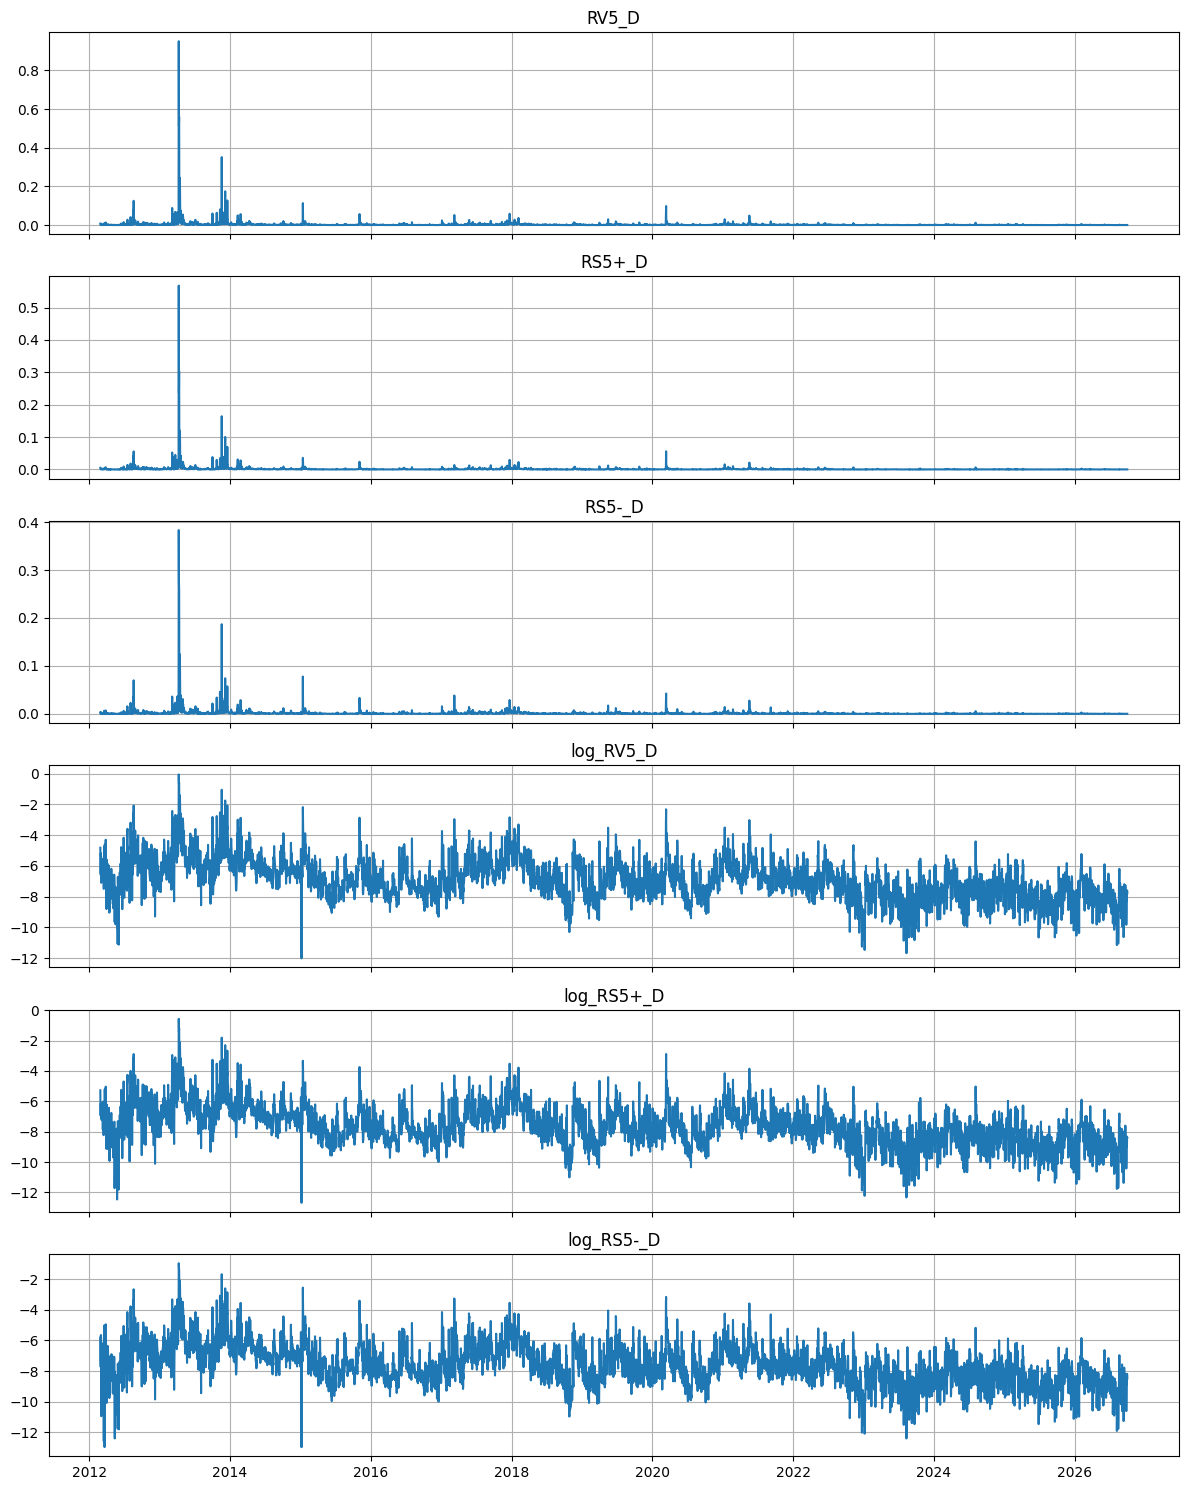

In [ ]:
# Select daily columns to plot
columns_to_plot = [col for col in daily_data.columns if "D" in col]

# Dynamically size the subplot rows based on the number of selected columns
fig, axes = plt.subplots(
    len(columns_to_plot), 1, figsize=(12, 2.5 * len(columns_to_plot)), sharex=True
)

# Ensure axes is iterable even if only 1 column matches
if len(columns_to_plot) == 1:
    axes = [axes]

for i, col in enumerate(columns_to_plot):
    axes[i].plot(daily_data[col])  # Plot from daily_data, not df
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
daily_data.columns

Index(['RV5_D', 'RS5+_D', 'RS5-_D', 'log_RV5_D', 'log_RS5+_D', 'log_RS5-_D',
       'RS5_asym_ratio', 'RS5+_W', 'RS5-_W', 'RV5_W', 'log_RS5+_W',
       'log_RS5-_W', 'log_RV5_W', 'RS5+_M', 'RS5-_M', 'RV5_M', 'log_RS5+_M',
       'log_RS5-_M', 'log_RV5_M', 'RV_target', 'target_log_RV'],
      dtype='object')

In [ ]:
def lin_reg(dataset, explanatory, target, cov_lags):
  x = dataset[explanatory]
  x = sm.add_constant(x)  # Add intercept beta_0
  y = dataset[target]
  model = sm.OLS(y, x).fit(cov_type='HAC',cov_kwds={'maxlags': cov_lags})
  return model.summary()

In [ ]:
features_rv = ['log_RV5_D', 'log_RV5_W', 'log_RV5_M', 'RS5_asym_ratio']

features_rs = [
    'log_RS5+_D', 'log_RS5-_D',
    'log_RS5+_W', 'log_RS5-_W',
    'log_RS5+_M', 'log_RS5-_M'
]

har_rs = lin_reg(daily_data, features_rs, 'target_log_RV', 30)
print(har_rs)

har_rv = lin_reg(daily_data, features_rv, 'target_log_RV', 30)
print(har_rv)


                            OLS Regression Results                            
Dep. Variable:          target_log_RV   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     1760.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        08:39:35   Log-Likelihood:                -5973.9
No. Observations:                5330   AIC:                         1.196e+04
Df Residuals:                    5323   BIC:                         1.201e+04
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0264      0.073     -0.363      0.7